In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import tplquad
from scipy.special import spherical_jn

### the complete integral

$$U_D(R) = \int^\infty _0 \int^\infty _0 \int^\infty _0 k^2 j_0(kR) v_D(k) F(\rho) g(E)   r_1^2 j_0(kr_1) \rho_p(r_1)  r_2^2 j_0(kr_2) \rho_t(r_2) dk dr_1 dr_2$$

In [12]:
def integrate(k, r2, r1,
              R,
              c1=7999.00,
              c2=2134.25,
              c=1.2253,
              mu1=4,
              mu2=2.5,
              gamma=1.5124,
              n=1):

    # Density functions
#     projectile
    def density_p(r, rho_0=0.17, a=0.5, R_0=3.02):
        return rho_0/(1+np.exp((r-R_0)/a))
    
#     target
    def density_t(r, rho_0=0.17, a=0.5, R_0 = 3.02):
        return rho_0/(1+np.exp((r-R_0)/a))
    
    # g(E)
    def g(E_lab, A=16):
        return (1-0.002*E_lab/A)

    # Total density
    rho = density_p(r1) + density_t(r2)

    # Fourier transform of M3Y interaction
    vD = (
        (4*np.pi*c1/mu1) / (mu1**2 + k**2)
        -
        (4*np.pi*c2/mu2) / (mu2**2 + k**2)
    )

    # Density-dependent factor
    F = c * (1 - gamma * rho**n)

    return 8*(
        k**2
        * spherical_jn(0, k*R)
        * vD
        * F
        * g(E_lab=145)
        * r1**2
        * r2**2
        * spherical_jn(0, k*r1)
        * spherical_jn(0, k*r2)
        * density_p(r1)
        * density_t(r2)
    )

In [13]:
R_vals = np.array([0.5*i for i in range(17)])

In [14]:
datas = []
errors = []

In [15]:
for i in range(0,17):

    result, error = tplquad(
        integrate,

        # r1: outer integral
        0, 8,

        # r2: middle integral
        lambda r1: 0,
        lambda r1: 8,

        # k: inner integral
        lambda r1, r2: 0,
        lambda r1, r2: 5,

        args=(R_vals[i],)
    )
    
    datas.append(result)
    errors.append(error)

In [16]:
len(datas)

17

In [17]:
R = np.linspace(0,8,17)

In [18]:
datas

[-146.49462372793323,
 -145.67080735039886,
 -142.84307308205504,
 -137.2837899203869,
 -128.5527651807801,
 -116.87916862650633,
 -103.0898148541064,
 -88.29092201422011,
 -73.5590658720024,
 -59.73992426589666,
 -47.336208000821586,
 -36.49869337885575,
 -27.162831696283714,
 -19.267715587900508,
 -12.866248376714083,
 -8.025969776171085,
 -4.668365010700288]

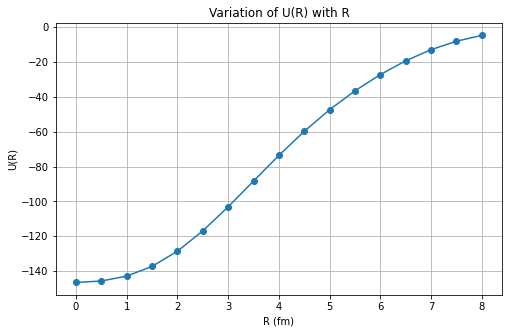

In [19]:
R_vals = np.array([0.5*i for i in range(17)])

plt.figure(figsize=(8, 5))

plt.plot(R_vals, datas, marker='o')

plt.xlabel('R (fm)')
plt.ylabel('U(R)')
plt.title('Variation of U(R) with R')

plt.grid(True)
plt.show()